PROJECT_ROOT : /Users/arifhossen/Documents/shift_aware_conformal
OUTPUT_ROOT  : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs
FIG_DIR      : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step5_joint_analysis_figures
STEP2_PATH : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step2_cifar10c_results_raps.csv
STEP3_PATH : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_cifar10c.csv
STEP4_PATH : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step4_weighted_conformal_results_stabilized.csv

Loaded rows:
Step 2: 40
Step 3: 40
Step 4: 40
Available alphas: [0.05, 0.1]
Available deltas: [0.05, 0.1]

Saved full merged CSV: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step5_joint_analysis_full.csv
Saved primary CSV    : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware

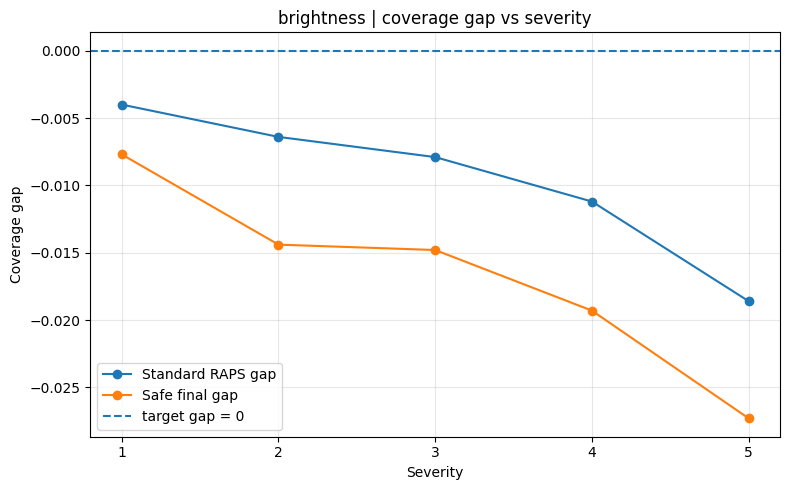

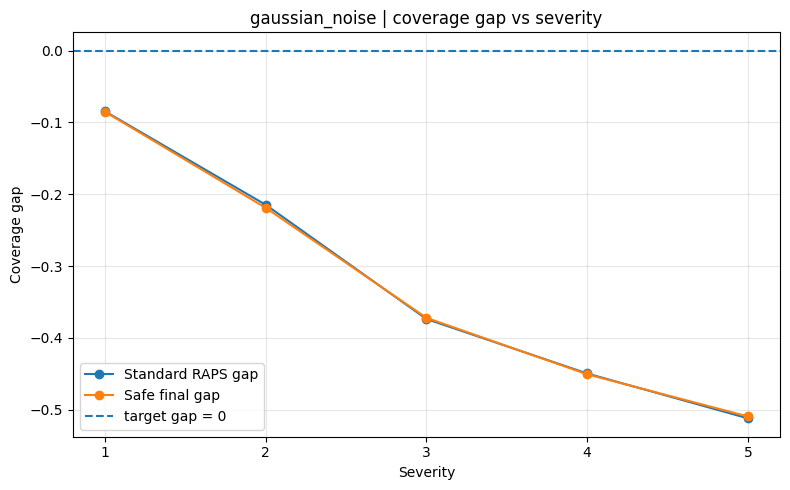

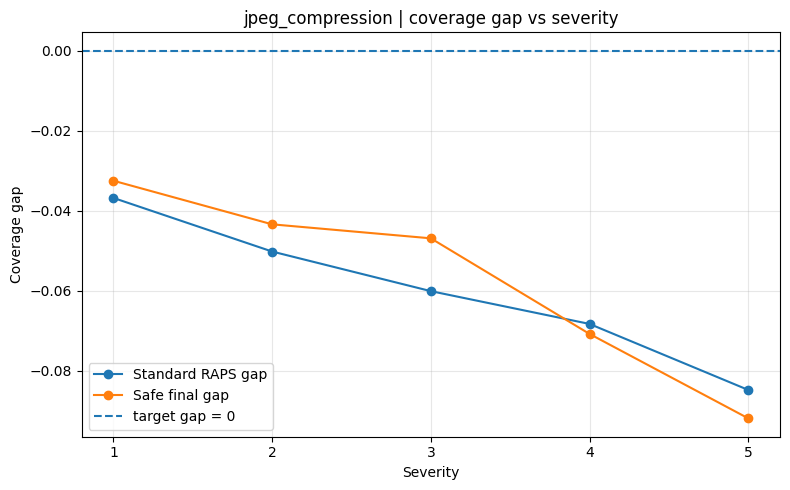

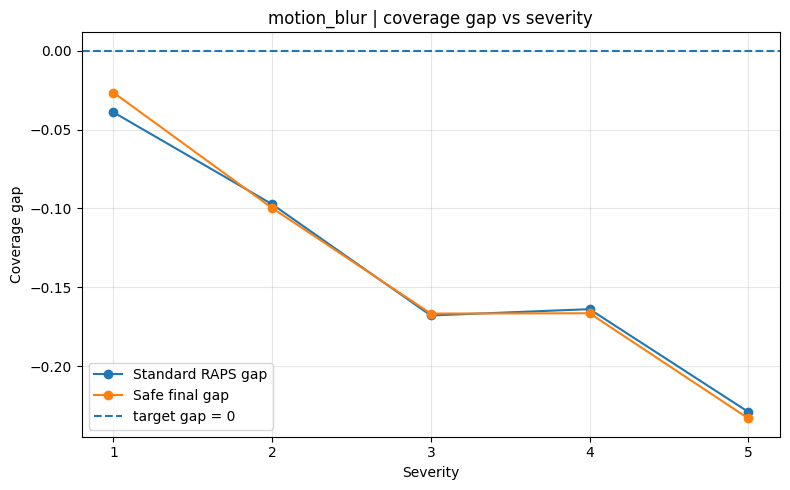

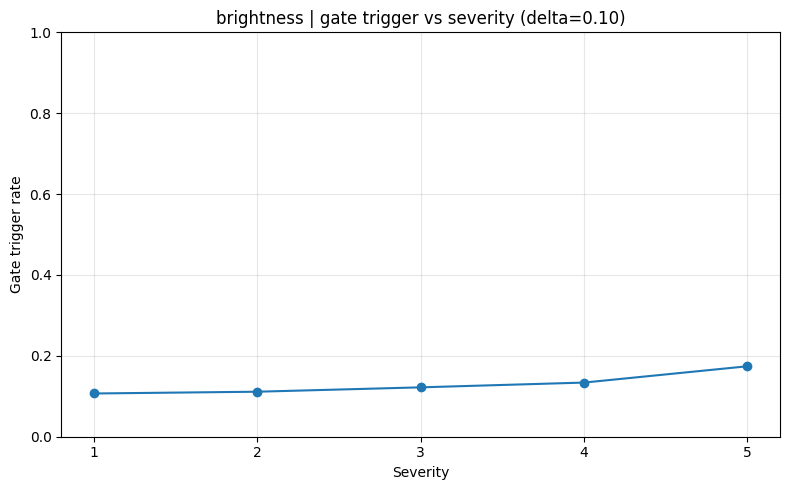

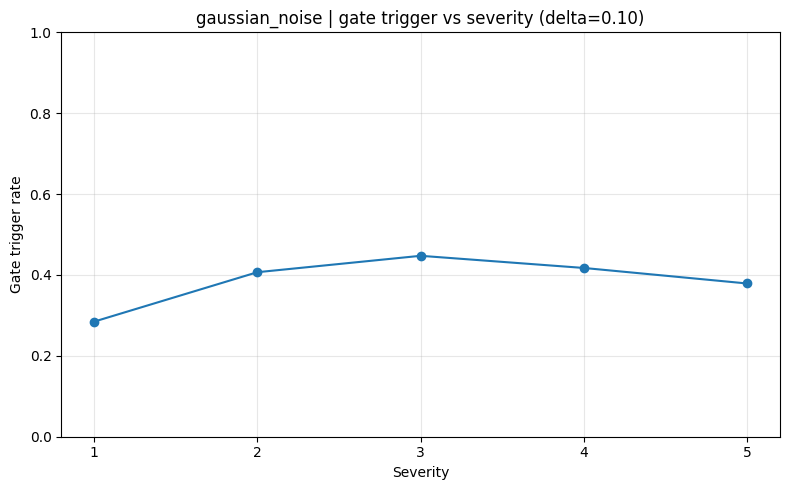

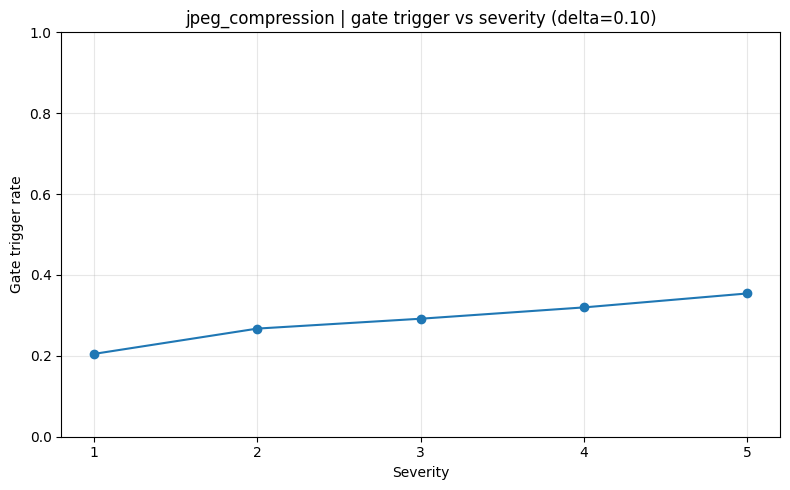

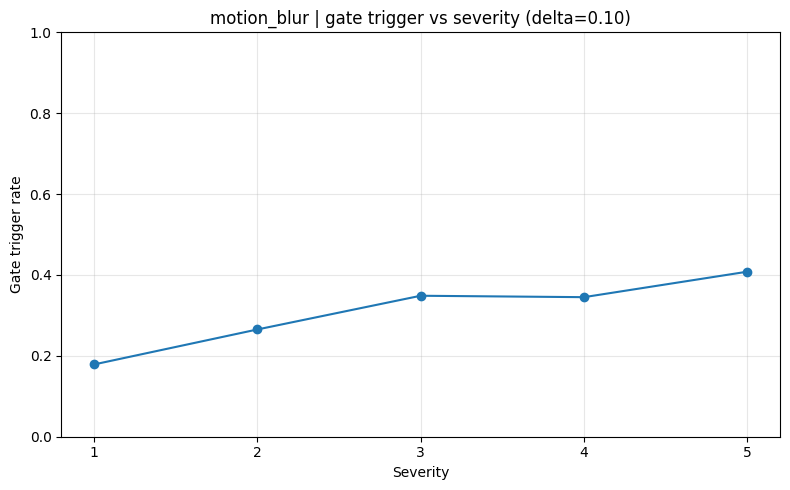

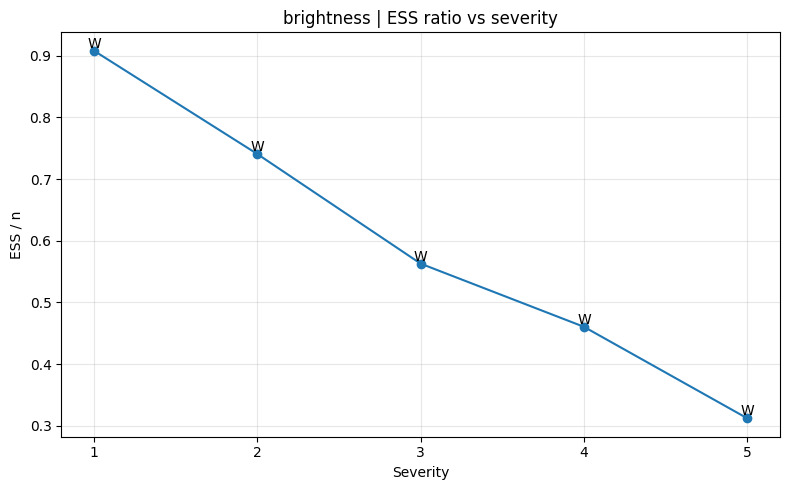

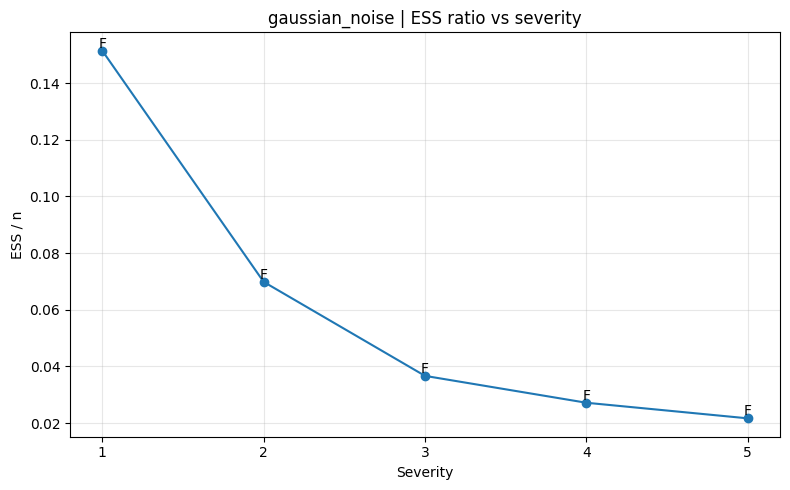

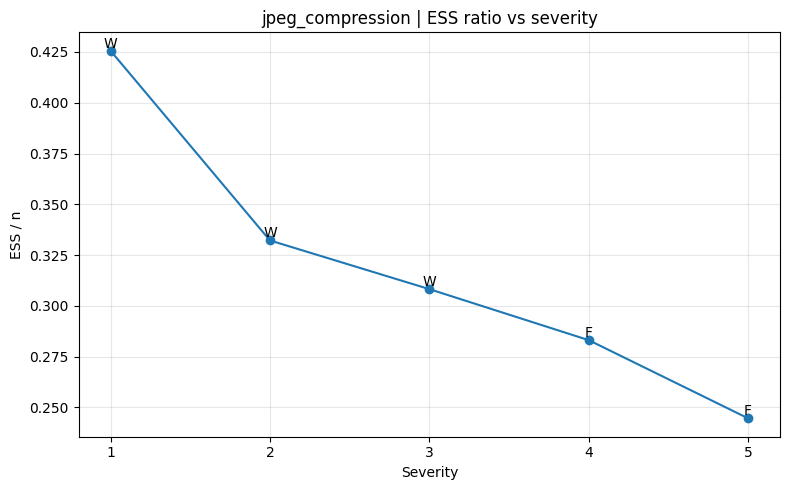

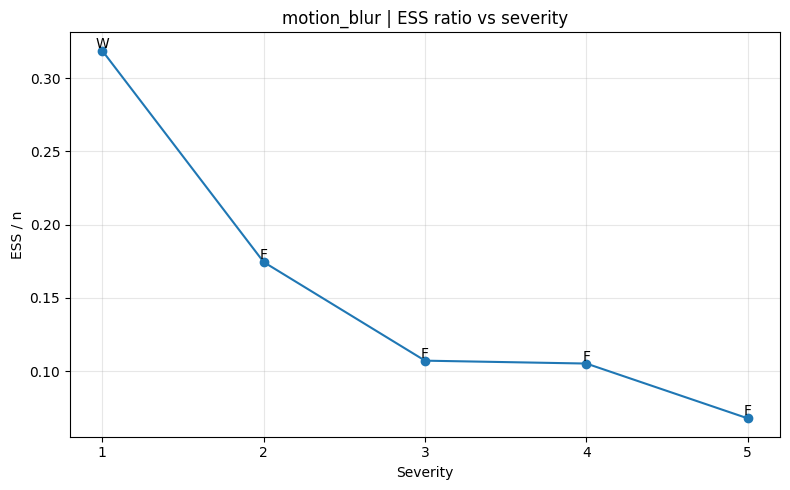

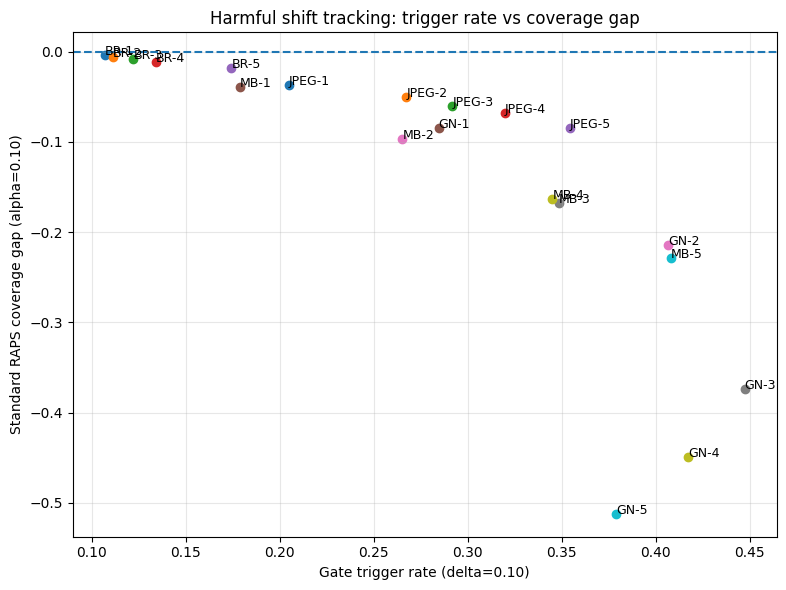

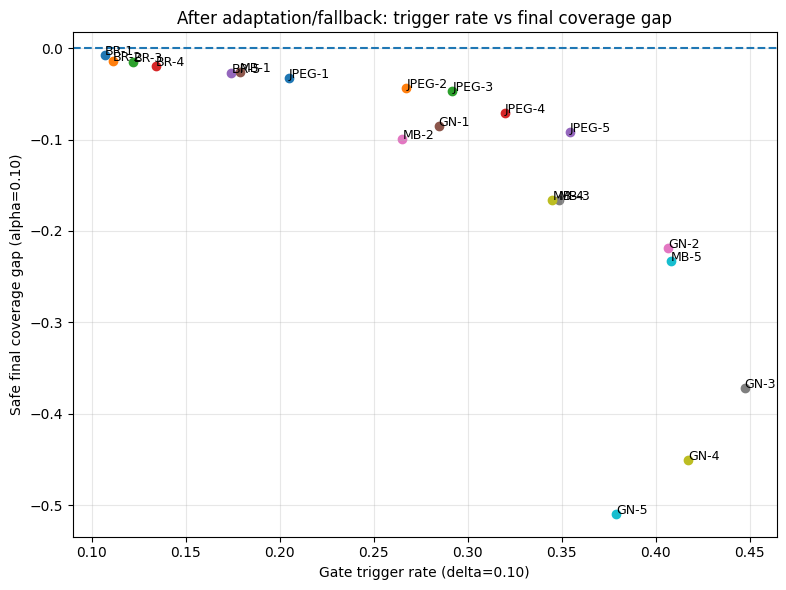

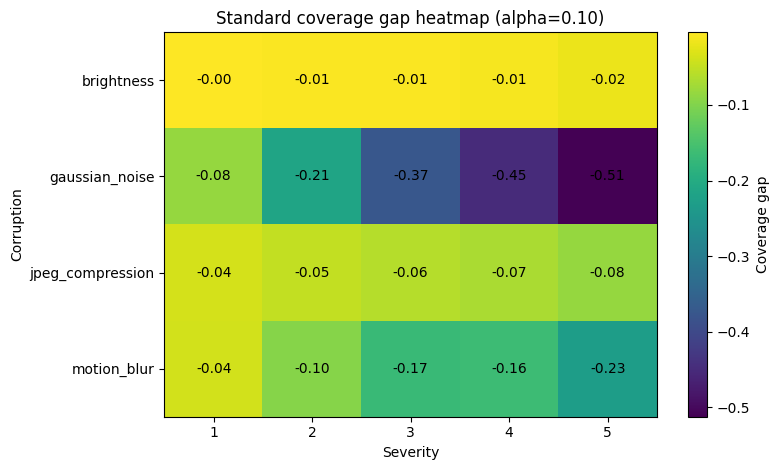

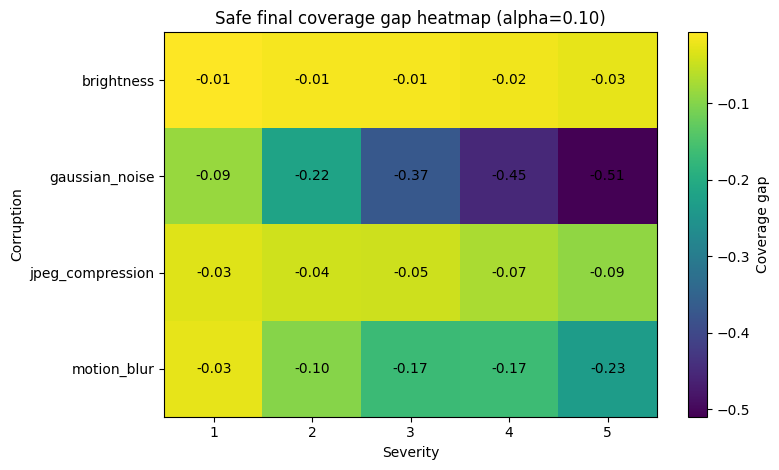

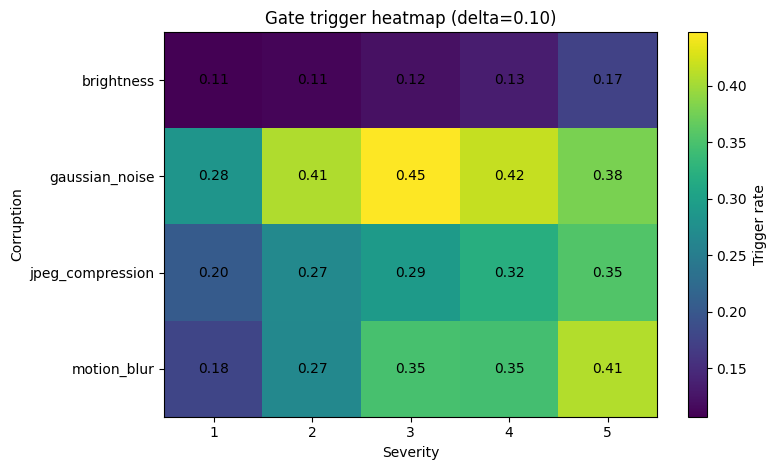

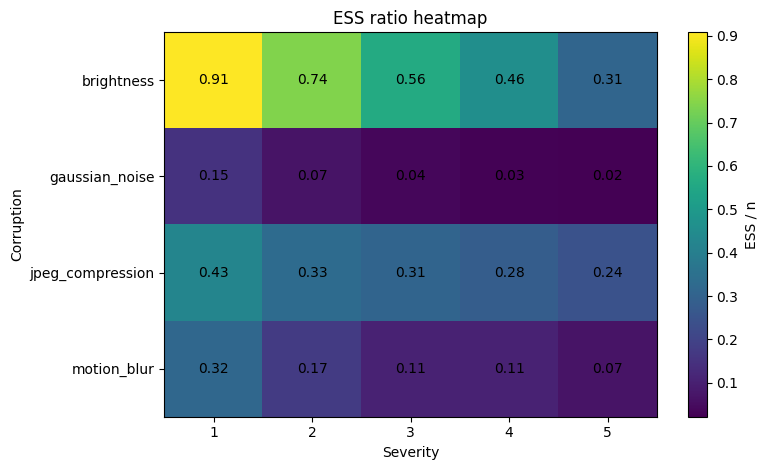

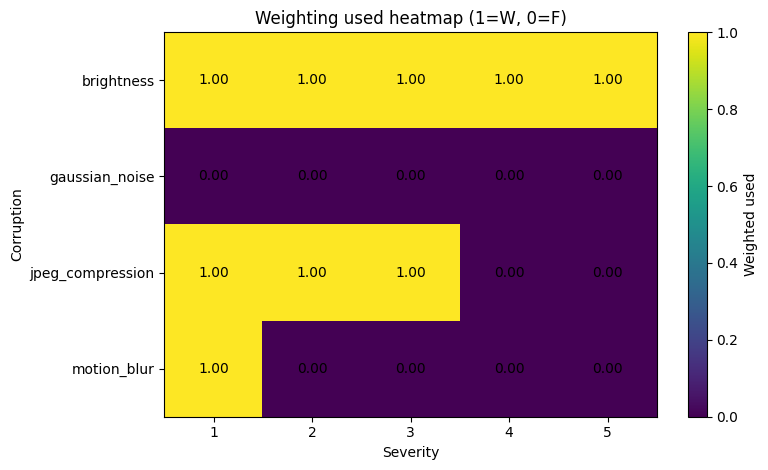


Saved figures in: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step5_joint_analysis_figures
Step 5 joint analysis finished.


In [1]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
PROJECT_ROOT = os.getcwd()
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_outputs")
FIG_DIR = os.path.join(OUTPUT_ROOT, "step5_joint_analysis_figures")
os.makedirs(FIG_DIR, exist_ok=True)

STEP2_CANDIDATES = [
    os.path.join(OUTPUT_ROOT, "step2_cifar10c_results_raps.csv"),
    os.path.join(OUTPUT_ROOT, "step2_cifar10c_results.csv"),
]

STEP3_CANDIDATES = [
    os.path.join(OUTPUT_ROOT, "step3b_energy_gate_cifar10c.csv"),
]

STEP4_CANDIDATES = [
    os.path.join(OUTPUT_ROOT, "step4_weighted_conformal_results_stabilized.csv"),
    os.path.join(OUTPUT_ROOT, "step4_weighted_conformal_results.csv"),
]

FULL_CSV = os.path.join(OUTPUT_ROOT, "step5_joint_analysis_full.csv")
PRIMARY_CSV = os.path.join(OUTPUT_ROOT, "step5_joint_analysis_primary.csv")
RESULTS_NPZ = os.path.join(OUTPUT_ROOT, "step5_joint_analysis_results.npz")

# Main paper operating point
PRIMARY_ALPHA = 0.10
PRIMARY_DELTA = 0.10

print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUTPUT_ROOT  :", OUTPUT_ROOT)
print("FIG_DIR      :", FIG_DIR)

# ============================================================
# Helpers
# ============================================================
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def maybe_number(x):
    if x is None:
        return x
    x = str(x).strip()
    if x == "":
        return x

    low = x.lower()
    if low == "true":
        return True
    if low == "false":
        return False

    try:
        if any(c in x for c in [".", "e", "E"]):
            return float(x)
        return int(x)
    except ValueError:
        try:
            return float(x)
        except ValueError:
            return x

def load_csv_rows(path):
    with open(path, "r", newline="") as f:
        reader = csv.DictReader(f)
        rows = []
        for row in reader:
            clean = {k: maybe_number(v) for k, v in row.items()}
            rows.append(clean)
    return rows

def write_csv(path, rows):
    if not rows:
        raise ValueError(f"No rows to write for {path}")
    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def build_index(rows, key_fields):
    out = {}
    for row in rows:
        key = tuple(row[k] for k in key_fields)
        out[key] = row
    return out

def float_eq(a, b, eps=1e-12):
    return abs(float(a) - float(b)) < eps

def short_name(corruption):
    mapping = {
        "gaussian_noise": "GN",
        "motion_blur": "MB",
        "brightness": "BR",
        "jpeg_compression": "JPEG",
    }
    return mapping.get(corruption, corruption)

# ============================================================
# Find files
# ============================================================
STEP2_PATH = first_existing(STEP2_CANDIDATES)
STEP3_PATH = first_existing(STEP3_CANDIDATES)
STEP4_PATH = first_existing(STEP4_CANDIDATES)

if STEP2_PATH is None:
    raise FileNotFoundError("Could not find Step 2 CSV.")
if STEP3_PATH is None:
    raise FileNotFoundError("Could not find Step 3B CSV.")
if STEP4_PATH is None:
    raise FileNotFoundError("Could not find Step 4 CSV.")

print("STEP2_PATH :", STEP2_PATH)
print("STEP3_PATH :", STEP3_PATH)
print("STEP4_PATH :", STEP4_PATH)

# ============================================================
# Load rows
# ============================================================
step2_rows = load_csv_rows(STEP2_PATH)
step3_rows = load_csv_rows(STEP3_PATH)
step4_rows = load_csv_rows(STEP4_PATH)

print("\nLoaded rows:")
print("Step 2:", len(step2_rows))
print("Step 3:", len(step3_rows))
print("Step 4:", len(step4_rows))

# ============================================================
# Build indices
# ============================================================
# Step 2 key: corruption, severity, alpha
step2_index = build_index(step2_rows, ["corruption", "severity", "alpha"])

# Step 3 key: corruption, severity, delta
step3_index = build_index(step3_rows, ["corruption", "severity", "delta"])

# Step 4 key: corruption, severity, alpha
step4_index = build_index(step4_rows, ["corruption", "severity", "alpha"])

all_deltas = sorted({float(r["delta"]) for r in step3_rows})
all_alphas = sorted({float(r["alpha"]) for r in step2_rows})

print("Available alphas:", all_alphas)
print("Available deltas:", all_deltas)

# ============================================================
# Merge all results
# ============================================================
full_rows = []

for (corruption, severity, alpha), s2 in step2_index.items():
    s4 = step4_index.get((corruption, severity, alpha), None)
    if s4 is None:
        continue

    for delta in all_deltas:
        s3 = step3_index.get((corruption, severity, delta), None)
        if s3 is None:
            continue

        full_rows.append({
            "corruption": corruption,
            "severity": int(severity),
            "alpha": float(alpha),
            "delta": float(delta),

            # Step 2 baseline shifted RAPS
            "coverage_standard": float(s2["empirical_coverage"]),
            "coverage_gap_standard": float(s2["coverage_gap"]),
            "avg_set_size_standard": float(s2["avg_set_size"]),

            # Step 3B conformal energy gate
            "gate_trigger_rate": float(s3["trigger_rate"]),
            "gate_threshold": float(s3["threshold"]),
            "energy_mean": float(s3["energy_mean"]),
            "energy_std": float(s3["energy_std"]),

            # Step 4 weighted / safe system
            "coverage_weighted": float(s4["coverage_weighted"]),
            "coverage_gap_weighted": float(s4["coverage_gap_weighted"]),
            "avg_set_size_weighted": float(s4["avg_set_size_weighted"]),

            "coverage_final": float(s4["coverage_final"]),
            "coverage_gap_final": float(s4["coverage_gap_final"]),
            "avg_set_size_final": float(s4["avg_set_size_final"]),

            "ess_ratio": float(s4["ess_ratio"]),
            "max_weight": float(s4["max_weight"]),
            "mean_weight": float(s4["mean_weight"]),
            "std_weight": float(s4["std_weight"]),

            "safe_to_weight": int(s4["safe_to_weight"]),
            "mode": s4["fallback_reason"],
        })

if not full_rows:
    raise ValueError("Merged table is empty. Check Step 2/3/4 CSV field names and files.")

write_csv(FULL_CSV, full_rows)
print("\nSaved full merged CSV:", FULL_CSV)

# ============================================================
# Primary paper table
# ============================================================
primary_rows = [
    r for r in full_rows
    if float_eq(r["alpha"], PRIMARY_ALPHA) and float_eq(r["delta"], PRIMARY_DELTA)
]
primary_rows = sorted(primary_rows, key=lambda x: (x["corruption"], x["severity"]))

if not primary_rows:
    raise ValueError(
        f"No primary rows found for alpha={PRIMARY_ALPHA}, delta={PRIMARY_DELTA}"
    )

write_csv(PRIMARY_CSV, primary_rows)
print("Saved primary CSV    :", PRIMARY_CSV)

# ============================================================
# Print compact joint table
# ============================================================
print("\n" + "=" * 110)
print(f"STEP 5 JOINT ANALYSIS TABLE (alpha={PRIMARY_ALPHA:.2f}, delta={PRIMARY_DELTA:.2f})")
print("=" * 110)

for row in primary_rows:
    print(
        f"{row['corruption']:20s} | sev={row['severity']} | "
        f"std_gap={row['coverage_gap_standard']:+.4f} | "
        f"final_gap={row['coverage_gap_final']:+.4f} | "
        f"std_size={row['avg_set_size_standard']:.4f} | "
        f"final_size={row['avg_set_size_final']:.4f} | "
        f"gate={row['gate_trigger_rate']:.4f} | "
        f"ESS={row['ess_ratio']:.4f} | "
        f"max_w={row['max_weight']:.2f} | "
        f"mode={row['mode']}"
    )

# ============================================================
# Corruption-level summary
# ============================================================
print("\n" + "=" * 110)
print("CORRUPTION-LEVEL SUMMARY")
print("=" * 110)

corruptions = sorted({r["corruption"] for r in primary_rows})

for corruption in corruptions:
    rows = [r for r in primary_rows if r["corruption"] == corruption]
    rows = sorted(rows, key=lambda x: x["severity"])

    avg_gate = np.mean([r["gate_trigger_rate"] for r in rows])
    worst_std_gap = min(r["coverage_gap_standard"] for r in rows)
    worst_final_gap = min(r["coverage_gap_final"] for r in rows)
    best_ess = max(r["ess_ratio"] for r in rows)
    used_count = sum(r["safe_to_weight"] for r in rows)

    print(
        f"{corruption:20s} | "
        f"avg gate={avg_gate:.4f} | "
        f"worst std gap={worst_std_gap:+.4f} | "
        f"worst final gap={worst_final_gap:+.4f} | "
        f"best ESS={best_ess:.4f} | "
        f"weighted used={used_count}/5"
    )

# ============================================================
# Save NPZ
# ============================================================
np.savez_compressed(
    RESULTS_NPZ,
    full_rows=np.array(full_rows, dtype=object),
    primary_rows=np.array(primary_rows, dtype=object),
)

print("\nSaved NPZ            :", RESULTS_NPZ)

# ============================================================
# Figure 1: Coverage gap vs severity (standard vs final)
# ============================================================
for corruption in corruptions:
    rows = [r for r in primary_rows if r["corruption"] == corruption]
    rows = sorted(rows, key=lambda x: x["severity"])

    xs = [r["severity"] for r in rows]
    y_std = [r["coverage_gap_standard"] for r in rows]
    y_final = [r["coverage_gap_final"] for r in rows]

    plt.figure(figsize=(8, 5))
    plt.plot(xs, y_std, marker="o", label="Standard RAPS gap")
    plt.plot(xs, y_final, marker="o", label="Safe final gap")
    plt.axhline(0.0, linestyle="--", label="target gap = 0")
    plt.xlabel("Severity")
    plt.ylabel("Coverage gap")
    plt.title(f"{corruption} | coverage gap vs severity")
    plt.xticks(xs)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, f"coverage_gap_{corruption}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# ============================================================
# Figure 2: Gate trigger rate vs severity
# ============================================================
for corruption in corruptions:
    rows = [r for r in primary_rows if r["corruption"] == corruption]
    rows = sorted(rows, key=lambda x: x["severity"])

    xs = [r["severity"] for r in rows]
    ys = [r["gate_trigger_rate"] for r in rows]

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("Severity")
    plt.ylabel("Gate trigger rate")
    plt.title(f"{corruption} | gate trigger vs severity (delta={PRIMARY_DELTA:.2f})")
    plt.xticks(xs)
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, f"gate_trigger_{corruption}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# ============================================================
# Figure 3: ESS ratio vs severity with W/F markers
# ============================================================
for corruption in corruptions:
    rows = [r for r in primary_rows if r["corruption"] == corruption]
    rows = sorted(rows, key=lambda x: x["severity"])

    xs = [r["severity"] for r in rows]
    ys = [r["ess_ratio"] for r in rows]

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    for r in rows:
        label = "W" if r["safe_to_weight"] == 1 else "F"
        plt.text(r["severity"], r["ess_ratio"], label, ha="center", va="bottom")
    plt.xlabel("Severity")
    plt.ylabel("ESS / n")
    plt.title(f"{corruption} | ESS ratio vs severity")
    plt.xticks(xs)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, f"ess_ratio_{corruption}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# ============================================================
# Figure 4: Scatter plot (gate trigger rate vs coverage gap)
# ============================================================
plt.figure(figsize=(8, 6))

for row in primary_rows:
    x = row["gate_trigger_rate"]
    y = row["coverage_gap_standard"]
    label = f"{short_name(row['corruption'])}-{row['severity']}"
    plt.scatter(x, y)
    plt.text(x, y, label, fontsize=9)

plt.axhline(0.0, linestyle="--")
plt.xlabel(f"Gate trigger rate (delta={PRIMARY_DELTA:.2f})")
plt.ylabel(f"Standard RAPS coverage gap (alpha={PRIMARY_ALPHA:.2f})")
plt.title("Harmful shift tracking: trigger rate vs coverage gap")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "scatter_gate_vs_standard_gap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# Figure 5: Scatter plot (gate trigger rate vs final coverage gap)
# ============================================================
plt.figure(figsize=(8, 6))

for row in primary_rows:
    x = row["gate_trigger_rate"]
    y = row["coverage_gap_final"]
    label = f"{short_name(row['corruption'])}-{row['severity']}"
    plt.scatter(x, y)
    plt.text(x, y, label, fontsize=9)

plt.axhline(0.0, linestyle="--")
plt.xlabel(f"Gate trigger rate (delta={PRIMARY_DELTA:.2f})")
plt.ylabel(f"Safe final coverage gap (alpha={PRIMARY_ALPHA:.2f})")
plt.title("After adaptation/fallback: trigger rate vs final coverage gap")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "scatter_gate_vs_final_gap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# Figure 6: Combined primary heatmaps
# ============================================================
severity_values = sorted({r["severity"] for r in primary_rows})

# coverage gap heatmap (standard)
matrix_std_gap = np.zeros((len(corruptions), len(severity_values)), dtype=np.float32)
matrix_final_gap = np.zeros((len(corruptions), len(severity_values)), dtype=np.float32)
matrix_gate = np.zeros((len(corruptions), len(severity_values)), dtype=np.float32)
matrix_ess = np.zeros((len(corruptions), len(severity_values)), dtype=np.float32)
matrix_mode = np.zeros((len(corruptions), len(severity_values)), dtype=np.float32)

for i, corruption in enumerate(corruptions):
    for j, severity in enumerate(severity_values):
        row = next(
            r for r in primary_rows
            if r["corruption"] == corruption and r["severity"] == severity
        )
        matrix_std_gap[i, j] = row["coverage_gap_standard"]
        matrix_final_gap[i, j] = row["coverage_gap_final"]
        matrix_gate[i, j] = row["gate_trigger_rate"]
        matrix_ess[i, j] = row["ess_ratio"]
        matrix_mode[i, j] = row["safe_to_weight"]

def save_heatmap(matrix, title, cbar_label, filename):
    plt.figure(figsize=(8, 4.8))
    im = plt.imshow(matrix, aspect="auto")
    plt.colorbar(im, label=cbar_label)
    plt.xticks(np.arange(len(severity_values)), severity_values)
    plt.yticks(np.arange(len(corruptions)), corruptions)
    plt.xlabel("Severity")
    plt.ylabel("Corruption")
    plt.title(title)
    for i in range(len(corruptions)):
        for j in range(len(severity_values)):
            plt.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()

save_heatmap(
    matrix_std_gap,
    f"Standard coverage gap heatmap (alpha={PRIMARY_ALPHA:.2f})",
    "Coverage gap",
    "heatmap_standard_gap.png"
)

save_heatmap(
    matrix_final_gap,
    f"Safe final coverage gap heatmap (alpha={PRIMARY_ALPHA:.2f})",
    "Coverage gap",
    "heatmap_final_gap.png"
)

save_heatmap(
    matrix_gate,
    f"Gate trigger heatmap (delta={PRIMARY_DELTA:.2f})",
    "Trigger rate",
    "heatmap_gate_trigger.png"
)

save_heatmap(
    matrix_ess,
    "ESS ratio heatmap",
    "ESS / n",
    "heatmap_ess_ratio.png"
)

save_heatmap(
    matrix_mode,
    "Weighting used heatmap (1=W, 0=F)",
    "Weighted used",
    "heatmap_weighted_used.png"
)

# ============================================================
# Final note
# ============================================================
print("\nSaved figures in:", FIG_DIR)
print("Step 5 joint analysis finished.")